# Exercises week 37

**FYS-STK3155/4155, fall 2026 — deadline Friday September 11 at midnight.**

## Implementing gradient descent for ordinary least squares and Ridge regression

The aim this week is that you write, and *check*, your own gradient descent
code for OLS and Ridge regression, and that you understand what the learning
rate can and cannot be. Everything here is reused directly in part e) of
Project 1, and exercise 6 opens part f). The code developed in the Tuesday
session (`week37tuesday.ipynb`, Case 1) is meant to be reused.

After completing these exercises you will have

* your own code for the simplest gradient descent approach applied to
  ordinary least squares (OLS) and Ridge regression, with a stopping criterion;
* compared the analytical expressions for the OLS and Ridge parameters with
  the gradient descent results;
* explored the role of the learning rate $\gamma$ in gradient descent and of the
  hyperparameter $\lambda$ in Ridge regression, and related the largest usable
  learning rate to the largest eigenvalue of the Hessian (Section 4.5 of the
  lecture notes);
* checked your analytical gradient against automatic differentiation
  (Section 4.14) and added momentum (Section 4.6);
* scaled the data properly.

Reading: Chapter 4, Sections 4.1–4.6 and 4.14 of the book; Goodfellow et al.,
Chapter 4 and Sections 8.1–8.3.

## A simple one-dimensional second-order polynomial

We start with a very simple function,

$$
f(x) = 2 - x + 5x^2,
$$

defined for $x \in [-2, 2]$. You can add noise if you wish (the Tuesday
session used Gaussian noise with standard deviation $0.5$). We fit this
function with a polynomial ansatz. The easiest thing is to set up a
second-order polynomial and see if you can recover the above function; feel
free to play around with higher-order polynomials — the Tuesday session shows
that a degree-5 fit of the same data is a much harder problem for gradient
descent, and exercise 4 asks you why.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)   # drop the noise term if you prefer

## Exercise 1: scale your data

Before fitting a regression model it is good practice to standardise the
features. This ensures all features are on a comparable scale, which is
especially important when using regularisation — and, as Section 4.5 of the
lecture notes shows, it is also what makes gradient descent converge in a
reasonable number of iterations. Here we standardise, scaling each feature to
have mean $0$ and standard deviation $1$.

### 1a)

Set up the design matrix $\boldsymbol{X}$ with the columns $x$ and $x^2$ (no
column of ones). Compute the mean and standard deviation of each column,
subtract the mean and divide by the standard deviation.

We also centre the target $\boldsymbol{y}$ to mean $0$. Centring
$\boldsymbol{y}$ and each feature means the model does not need a separate
intercept term: the data are shifted so that the intercept is effectively
$0$. (In practice one can include an intercept in the model and leave it
unpenalised, see Section 3.13 of the lecture notes; here we simplify by
centring.)

X norm mean:2.486899575160351e-16
X norm std: 0.9999999999999999
y mean: 7.401393075815739
y centered mean: -5.506706202140776e-16


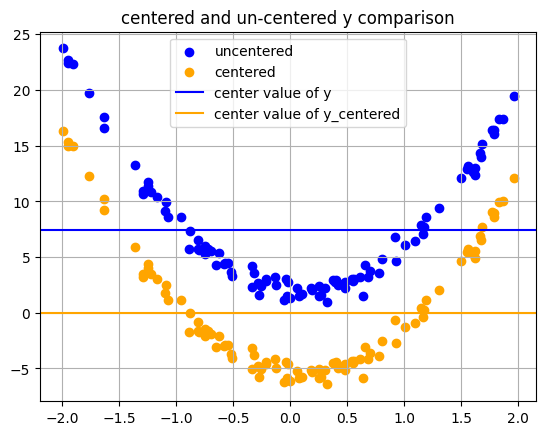

In [3]:
from sklearn.linear_model import LinearRegression

X = np.column_stack([x, x**2])

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = y.mean()
y_centered = y - y.mean()


print(f'X norm mean:{X_norm.mean()}')
print(f'X norm std: {X_norm.std()}')
print(f'y mean: {y.mean()}')
print(f'y centered mean: {y_centered.mean()}')


plt.scatter(x,y, label = 'uncentered', color = 'blue')
plt.scatter(x,y_centered, label = 'centered', color = 'orange')
plt.axhline(y.mean(), color = 'blue', label = 'center value of y')
plt.axhline(y_centered.mean(), label = 'center value of y_centered', color = 'orange')
plt.title('centered and un-centered y comparison')
plt.legend()
plt.grid()
plt.show()

Fill in the necessary details. Do we need to centre the $y$-values? What
would go wrong, for OLS and for Ridge, if we did not?

After this preprocessing each column of $\boldsymbol{X}_{\mathrm{norm}}$ has
mean zero and standard deviation $1$ and $\boldsymbol{y}_{\mathrm{centered}}$
has mean $0$. This makes the optimisation landscape nicer and ensures that the
penalty $\lambda\sum_j\theta_j^2$ in Ridge regression treats each coefficient
fairly, since the features are on the same scale.

### 1b)

The true function has coefficients $(-1, 5)$ on $(x, x^2)$. Which
coefficients do you expect to find on the *standardised* columns, and how do
you convert the fitted parameters back to the original scale?

### Part 1a)
The matrix is defined without the intercept, so the model will create predictions centered around 0. Therefore, we have to center y around 0 as well, to ensure that the model is able to reproduce $y$ correctly. 

If we dont center $y$, the OLS model will try to fit the parameters to the vertical offset. This will shift the parameters away from their true values and we get a biased fit. 


Ridge penalizes the coefficients magnitudes toward zero, but if $y$ is not centered, it will penalize the intercept as well. The location of the data has nothing to do with overfitting, so shrinking it introduces a systematic bias. All predictions gets pulled towards 0 regardless of where the data actually lies. 

To ensure correct estimates, we center $y$ before fitting Ridge. Since the mean of $X$ and $y$ is 0, the true intercept in the centered coordinates is exactly 0. Afterwards, we can just add $\bar{y}$ back to get predictions in the original scale.


### Part 1b)

When we standardise the columns in the matrix, we subtract the mean value, and then divide by the standard deviation $\sigma$. We do not need to further include the mean, as it can be considered a part of the intercept. 


Since the coefficitnes of ($x, x^2$) is (-1, 5), we should expect something like $\left( -\sigma(x), 5 \cdot \sigma(x^2)\right)$. The sign and relative size of the true coefficients survive, but the magnitude is scaled to the standard deviation of their columns. In order to convert the predicted parameters back to our original scale, we just divide them by $\sigma$.


## Exercise 2: calculate the gradients and the Hessian

Find the gradients of the OLS and Ridge cost functions,

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2,
\qquad
C_{\mathrm{Ridge}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 + \lambda\boldsymbol{\theta}^T\boldsymbol{\theta},
$$

with respect to $\boldsymbol{\theta}$ (Eqs. (4.13) and (4.17) of the lecture
notes). Find also the Hessian matrices, and show that the OLS Hessian is
positive semi-definite and the Ridge Hessian positive definite for
$\lambda > 0$ — that is, that both cost functions are convex (Section 4.1).
Why does this matter for gradient descent?

Setting the Ridge gradient to zero, show that the minimiser is
$\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^T\boldsymbol{y}$.
Where does the factor $n$ come from, and what is the corresponding `alpha`
of `scikit-learn`'s `Ridge`? (Section 3.10 and Eq. (3.95).)

## Exercise 3: the analytical formulae for OLS and Ridge regression

In [4]:
# Set regularization parameter, either a single value or a vector of values
# Note that lambda is a python keyword: the lambda keyword creates small anonymous functions.
lam = 0.5

# Analytical forms: theta_Ridge = (X^T X + n*lambda*I)^{-1} X^T y and theta_OLS = (X^T X)^{-1} X^T y
n_features = X_norm.shape[1]
I = np.eye(n_features)
theta_closed_formRidge = np.linalg.solve(X_norm.T @ X_norm + n * lam * I, X_norm.T @ y_centered)
theta_closed_formOLS = np.linalg.solve(X_norm.T @ X_norm, X_norm.T @ y_centered)


print("Closed-form Ridge coefficients:", theta_closed_formRidge)
print("Closed-form OLS coefficients:", theta_closed_formOLS)

Closed-form Ridge coefficients: [-0.5608836   3.86236727]
Closed-form OLS coefficients: [-1.0773505  5.854734 ]


This computes the Ridge and OLS regression coefficients directly. The identity
matrix $\boldsymbol{I}$ has the same size as $\boldsymbol{X}^T\boldsymbol{X}$
and adds $n\lambda$ to its diagonal for Ridge regression. We then solve the
linear system (prefer `np.linalg.solve` or `np.linalg.pinv` to an explicit
inverse). The result for $\boldsymbol{\theta}$ is a NumPy array of shape
`(n_features,)` containing the fitted parameters.

### 3a)

Finalise, in the above code, the OLS and Ridge regression determination of
the optimal parameters $\boldsymbol{\theta}$. Compare with
`Ridge(alpha=n*lam, fit_intercept=False)` from `scikit-learn`.

### 3b)

Explore the results as functions of different values of the hyperparameter
$\lambda$. See for example exercise 4 from week 36, and Section 3.14 of the
lecture notes for how $\lambda$ should be chosen in practice.

### Part 3a)

In [5]:
from sklearn.linear_model import Ridge

model_scikitRidge = Ridge(alpha=n*lam, fit_intercept=False).fit(X_norm, y_centered)
theta_scikitRidge = model_scikitRidge.coef_

print(f'Ridge coefficients using scikit:" {theta_scikitRidge}')

Ridge coefficients using scikit:" [-0.5608836   3.86236727]


The ridge coefficients from scikit-learn are identical to the closed-form ridge coefficient from the analytical calculations. 

### Part 3b)

Lambda | Closed-form Ridge coefficients
--------------------------------------------------------------------------------
 0.001 | [-1.07555692  5.84867285]
  0.01 | [-1.0596409   5.79468915]
   0.1 | [-0.92026706  5.30556833]
     1 | [-0.36277337  2.88504092]
  10.0 | [-0.0405001   0.52108217]
 100.0 | [-0.00386623  0.05670855]
1000.0 | [-0.00038406  0.00572143]


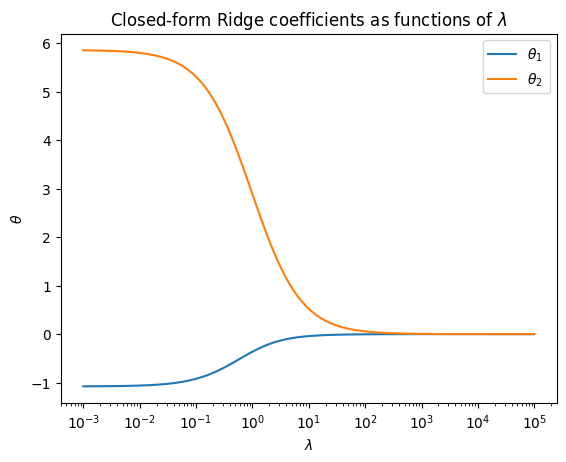

In [6]:
def Ridge_Coeffs(lam):
    n_features = X_norm.shape[1]
    I = np.eye(n_features)
    theta_closed_formRidge = np.linalg.solve(X_norm.T @ X_norm + n * lam * I, X_norm.T @ y_centered)

    return theta_closed_formRidge

lambda_values = np.logspace(-3, 5, 100)
theta_x = np.zeros(len(lambda_values))
theta_x2 = np.zeros(len(lambda_values))

for i in range(len(lambda_values)):
    theta = Ridge_Coeffs(lambda_values[i])
    theta_x[i] = theta[0]
    theta_x2[i] = theta[1]

print(f'Lambda | Closed-form Ridge coefficients')
print('-' * 80)
selected_lam = (1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3)
for l in selected_lam:
    coeffs = Ridge_Coeffs(l)

    print(f'{l:>6} | {coeffs}')


plt.plot(lambda_values, theta_x, label = r'$\theta_1$ ')
plt.plot(lambda_values, theta_x2, label = r'$\theta_2$ ')
plt.xscale('log')
plt.title(r'Closed-form Ridge coefficients as functions of $\lambda$')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.show()


As $(\lambda \rightarrow -\infty)$, both coefficients converge towards the OLS values. No penalty means that Ridge reduces exactly th OLS.  

As $(\lambda \rightarrow \infty)$, the coefficients are pushed towards 0. The penalty overwhelms the data-fit term and predicts the mean everywhere, giving $\theta = 0$.

Overall, we see that the shrinkage isn't uniform. $\theta_2$ is 5.85 at the beginning and starts bending around $\lambda \approx 0.1$, while $\theta_1$ is smaller in the beginning. 

## Exercise 4: implementing the simplest form of gradient descent

Alternatively we can fit the model by gradient descent, Eq. (4.15) of the
lecture notes,

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \gamma\,\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k).
$$

This is useful to visualise the iterative convergence, and it is necessary
when $n$ and $p$ are so large that the closed form is too slow or too
memory-hungry — or when, as for the Lasso, logistic regression and neural
networks, no closed form exists. Use the gradients of exercise 2 and set up,
using the template below, your own gradient descent code for OLS and Ridge
regression.

In [7]:
# Gradient descent parameters, learning rate gamma first
gamma = 0.1
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 1000
tol = 1e-8

# Initialize weights for gradient descent
theta_gdOLS = np.zeros(n_features)
theta_gdRidge = np.zeros(n_features)

# Gradient descent loop
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_OLS = ?
    grad_Ridge = ?
    # Update parameters theta
    theta_gdOLS = ?
    theta_gdRidge = ?
    # Stopping criterion: ?

# After the loop, theta contains the fitted coefficients
print("Gradient Descent OLS coefficients:", theta_gdOLS)
print("Gradient Descent Ridge coefficients:", theta_gdRidge)


SyntaxError: invalid syntax (2838807546.py, line 14)

### 4a)

Write first a gradient descent code for OLS only, using the above template.
Discuss the results as functions of the learning rate and the number of
iterations: for $\gamma \in \{0.01, 0.1, 0.5, 0.8\}$, how many iterations are
needed to reach the closed-form solution of exercise 3 to a given accuracy,
say $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$?
Plot this distance against the iteration number on a logarithmic scale.

In [ ]:
# Gradient descent parameters, learning rate gamma first
gamma = 0.1
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 20000
tol = 1e-8

def gradient_OLS(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y)  + 2.0 * lam * theta


def gradient_descent_OLS(X, y, eta, lam=0.0, theta0=None):
    """Plain gradient descent, Eq. (4.15). Returns the iterates and the number of steps."""
    # Initialize weights for gradient descent
    theta = theta0.copy() if theta0 is not None else np.zeros(n_features)
    history = [theta.copy()]

    # Gradient descent loop
    for t in range(num_iters):
        # Compute gradients for OLS and Ridge
        grad = gradient_OLS(theta, X, y, lam = lam)

        # Update parameters theta
        theta = theta - eta * grad
        history.append(theta.copy())
        
        '''print("Gradient Descent OLS coefficients:", theta_gdOLS)'''

        if np.linalg.norm(grad_OLS) < tol:
            break
    return np.array(history), t + 1


def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

theta_hat = closed_form(X_norm, y_centered, lam = 0.0)

for eta in (0.01, 0.1, 0.5, 0.8):
    history_theta, iteration_t = gradient_descent_OLS(X_norm, y_centered, eta)
    theta_final = history_theta[-1]
    err = np.linalg.norm(history_final - theta_hat)
    status = 'converged' if iteration_t < 20000 and np.isfinite(err) else ('diverged' if not np.isfinite(err) or err > 1e6 else 'not converged')
    print(f'eta = {eta}: {iteration_t} iterations, |theta - closed form| = {err} {status}')
    




        err = np.linalg.norm(history_theta[-1] - theta_hat)
        status = "converged" if iteration_t < 20000 and np.isfinite(err) else ("DIVERGED" if not np.isfinite(err) or err > 1e6 else "not converged")
        print(f"   learning rate eta = {eta:<5}: {iteration_t:6d} iterations, |theta - closed form| = {err:9.2e}   {status}")


IndentationError: unexpected indent (2283737567.py, line 53)

### 4b)

Write then a similar code for Ridge regression. Add a stopping criterion
based on the number of iterations *and* on the size of the gradient (or on
the difference between the new and old $\boldsymbol{\theta}$). How would you
define a stopping criterion, and what goes wrong with a fixed number of
iterations alone?



In [ ]:
# Gradient descent parameters, learning rate gamma first
gamma = 0.1
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 1000
tol = 1e-8

# Initialize weights for gradient descent
theta_gdRidge = np.zeros(n_features)

# Gradient descent loop
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = ?
    # Update parameters theta
    theta_gdRidge = ?
    # Stopping criterion: ?

# After the loop, theta contains the fitted coefficients
print("Gradient Descent Ridge coefficients:", theta_gdRidge)

### 4c) The learning rate and the eigenvalues of the Hessian

Compute the eigenvalues $\lambda_{\max}$ and $\lambda_{\min}$ of the Hessian
matrix of exercise 2 (use `np.linalg.eigvalsh`). Section 4.5 of the lecture
notes shows that gradient descent converges if and only if
$\gamma < 2/\lambda_{\max}$, Eq. (4.20), that the fastest convergence is
obtained for $\gamma^* = 2/(\lambda_{\max} + \lambda_{\min})$, and that the
number of iterations grows with the condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.21). Verify the bound
numerically: run your code at $0.99 \cdot 2/\lambda_{\max}$ and at
$1.02 \cdot 2/\lambda_{\max}$.

Repeat for a design matrix with the columns $x, x^2, \dots, x^5$
(standardised). What happens to $\kappa$, to $\gamma_{\max}$ and to the number
of iterations, and why? Which of the two data sets does Ridge regression help
more, and in what sense?


### 4d) Checking the gradient with automatic differentiation

Project 1, part e), asks you to compute the gradient in two independent ways:
analytically, and by automatic differentiation. Write the OLS and Ridge cost
functions as ordinary Python functions of $\boldsymbol{\theta}$ using
`jax.numpy`, obtain their gradients with `jax.grad`, and compare with your
analytical gradients from exercise 2 at a random $\boldsymbol{\theta}$
(Section 4.14.7 of the lecture notes; remember
`jax.config.update("jax_enable_x64", True)`). Run your gradient descent code
with the automatic gradient and check that you obtain the same iterates.

In one or two sentences: why is automatic differentiation neither symbolic
nor numerical (finite-difference) differentiation, and what does a gradient
cost relative to one evaluation of the cost function (Section 4.14.4)?

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import grad

def cost_OLS(theta, X, y):
    return ?

def cost_Ridge(theta, X, y, lam):
    return ?

theta_test = rng.standard_normal(n_features)
grad_OLS_ad = grad(cost_OLS)(theta_test, jnp.asarray(X_norm), jnp.asarray(y_centered))
grad_OLS_analytical = ?
print("max |AD - analytical| =", np.max(np.abs(np.asarray(grad_OLS_ad) - grad_OLS_analytical)))

## Exercise 5: Ridge regression and a new synthetic data set

We create a synthetic linear regression data set with a sparse underlying
relationship: many features, of which only a few contribute to the target. We
use 10 features with only 3 non-zero weights in the true model, so that the
target is a linear combination of a few features (with known coefficients)
plus random noise. The steps are:

* decide on the number of samples and features (100 samples, 10 features);
* define the *true* coefficient vector with mostly zeros, for example
  $\boldsymbol{\theta}_{\mathrm{true}} = [5.0, -3.0, 0, 0, 0, 0, 2.0, 0, 0, 0]$,
  meaning only features 0, 1 and 6 have a real effect on $y$;
* sample the feature matrix $\boldsymbol{X}$ from a standard normal
  distribution, so that the features are roughly centred around 0;
* compute $\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta}_{\mathrm{true}} + \boldsymbol{\varepsilon}$
  with Gaussian noise $\boldsymbol{\varepsilon}$.

In [ ]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

# Define dataset size
n_samples = 100
n_features = 10

# Define true coefficients (sparse linear relationship)
theta_true = np.array([5.0, -3.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0])

# Generate feature matrix X (n_samples x n_features) with random values
X = np.random.randn(n_samples, n_features)  # standard normal distribution

# Generate target values y with a linear combination of X and theta_true, plus noise
noise = 0.5 * np.random.randn(n_samples)    # Gaussian noise
y = X @ theta_true + noise

This code produces a data set where only features 0, 1 and 6 significantly
influence $\boldsymbol{y}$; the rest have zero true coefficient. Feature 0 has
a true weight of $5.0$, feature 1 of $-3.0$ and feature 6 of $2.0$, so the
expected relationship is

$$
y \approx 5x_0 - 3x_1 + 2x_6 + \text{noise}.
$$

You can remove the noise if you wish.

Fit the above data set using OLS and Ridge regression with the analytical
expressions and with your own gradient descent code (scale the data as in
exercise 1). If everything works, the learned coefficients should be close to
the true values $[5.0, -3.0, 0, \dots, 2.0, \dots]$. Due to regularisation
and noise the learned values will not exactly equal the true ones, but they
should be in the same ballpark. Which method, OLS or Ridge, gives the best
results — and best in which sense? Compute the condition number of the
Hessian for this data set: why does gradient descent converge so much more
easily here than for the degree-5 polynomial of exercise 4c)?

## Exercise 6: adding momentum

Part f) of Project 1 asks you to extend your gradient descent code with
momentum and, next week, with the adaptive methods AdaGrad, RMSProp and Adam.
Start here with momentum, Eq. (4.23) of the lecture notes,

$$
\boldsymbol{v}_{k+1} = \beta\boldsymbol{v}_k + \gamma\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k),
\qquad
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1},
$$

which is one line more than the code of exercise 4. Use the degree-5
polynomial data of exercise 4c), where plain gradient descent is slow, and
the learning rate $\gamma = 0.9 \cdot 2/\lambda_{\max}$.

1. Run $\beta \in \{0, 0.5, 0.9\}$ and count the iterations needed to reach
   $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$. Plot
   the three convergence curves on a logarithmic scale.
2. Section 4.6 shows that, with optimally tuned parameters, momentum reduces
   the iteration count from $\propto\kappa$ to $\propto\sqrt\kappa$,
   Eq. (4.26). How large a reduction do you observe with the fixed $\gamma$
   above, and how does it compare with $\sqrt\kappa$? Try the optimal
   momentum $\beta^* = \big((\sqrt\kappa-1)/(\sqrt\kappa+1)\big)^2$.
3. Explain, in terms of Eqs. (4.24) and (4.25), why momentum speeds up the
   flat directions and damps the oscillations in the steep ones.
4. (Optional) Repeat with $\gamma = 1.5 \cdot 2/\lambda_{\max}$, where plain
   gradient descent diverges. What happens with momentum, and why?

In [ ]:
# Your momentum code here

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| My loop stopped after its allowed iterations with a small but nonzero gradient. Has it converged? | No. Along the slowest direction the error contracts by $\lvert 1-\gamma\lambda_{\min}\rvert$ per step, Eq. (4.19), and can still be $\|\nabla C\|/\lambda_{\min}$ large. Stop on the gradient (or on $\Delta\boldsymbol{\theta}$), never on a count alone. |
| Why does gradient descent care about the scaling of the columns when the closed form does not? | The closed form solves the normal equations in one go; gradient descent takes the same step in every direction, and the column scales set the eigenvalue spread $\kappa(\boldsymbol{H}) = \kappa_2(\boldsymbol{X})^2$, Eq. (4.22), hence the iteration count. Same minimum, different road. |
| Ridge converged in far fewer iterations than OLS. Did it find a better OLS solution? | No — it found the exact solution of a *different* problem, Eq. (4.16). The penalty lifts $\lambda_{\min}$, Eq. (4.17), which shortens the road, but the destination moved: bias traded for variance. |
| The same code diverged at $\gamma = 0.5$ on one data set and converged at $\gamma = 0.8$ on another. Why? | Stability requires $\gamma < 2/\lambda_{\max}$, Eq. (4.20), and $\lambda_{\max}$ is a property of $\boldsymbol{X}$, not of the algorithm. Compute it — `np.linalg.eigvalsh(2/n * X.T @ X).max()` — before you choose $\gamma$. |
| The closed form and my converged gradient descent disagree in the second decimal for Ridge. Which is wrong? | Possibly neither: with the cost $\frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|^2 + \lambda\|\boldsymbol{\theta}\|^2$ the closed form has $n\lambda\boldsymbol{I}$, Eq. (3.95), and `scikit-learn`'s `alpha` is $n\lambda$. Compare cost functions before comparing methods. |
| My JAX gradient agrees with my analytical gradient to $10^{-15}$. What have I proved? | That your derivation matches the cost you *wrote down* — an algebra error would show as $10^{-2}$. Not that the cost is the one you meant (a missing $1/n$, a penalised intercept): both gradients would then agree and both would be wrong. |
| Momentum converged where plain gradient descent diverged. Is the learning rate now unimportant? | No. The stability edge moves to $2(1+\beta)/\lambda_{\max}$, and the best $\beta$ is tied to $\kappa$ through Eq. (4.26); too much momentum rings for ever. Two data-dependent knobs instead of one. |
| Why does momentum help, in one sentence? | It adds up gradients that keep pointing the same way (the flat directions, effective step $\gamma/(1-\beta)$, Eq. (4.25)) and cancels gradients that alternate in sign (the steep direction), so the iteration count scales with $\sqrt\kappa$ instead of $\kappa$. |
| I swap the OLS cost for a neural-network cost and keep `jax.grad`. What changes? | In the code: only the definition of the cost. In the theory: convexity is gone, so a stationary point need not be the global minimum (Section 4.1) and the bound of Eq. (4.20) is only local — good behaviour becomes empirical, not a theorem. |
| Why reverse mode for training, and what is its price? | One scalar output and $p$ inputs: reverse mode returns the full gradient for two or three cost evaluations, whatever $p$ (the cheap gradient principle, Section 4.14.4); forward mode or finite differences would need $p$ sweeps. The price is the tape — every intermediate value is stored until the backward sweep has used it: memory, not time. |
| Why not just use finite differences to check the gradient, and be done with it? | For a *quadratic* cost the central difference is exact up to rounding, so it would pass; for anything else its best accuracy is about $10^{-11}$ at $h\approx10^{-6}$, Eq. (4.46), and it costs $2p$ evaluations. Use it as a check at $h \approx 10^{-5}$, not as the gradient. |

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 11 at midnight**. Collaboration is encouraged — list
your collaborators.